<a href="https://colab.research.google.com/github/MartinArshakyan/P.Neyronayin-Cancer/blob/main/Car_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# CELL 1 — Install & imports
# ============================================================
!pip install torch scikit-learn pandas numpy matplotlib --quiet

import pandas as pd
import numpy as np
import zipfile, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully.")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully.
PyTorch version: 2.10.0+cpu


In [14]:
# ============================================================
# CELL 2 — Synthetic car dataset (offline fallback)
# ============================================================
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

brands     = ['toyota','honda','mazda','bmw','audi','volkswagen','porsche','ford','chevrolet','alfa-romeo']
carbody    = ['sedan','hatchback','wagon','hardtop','convertible']
drivewheel = ['fwd','rwd','4wd']
enginetype = ['ohc','ohcv','ohcf','dohc','rotor','l']
cylinders  = ['four','six','five','eight','two','three','twelve']
fuelsystem = ['mpfi','2bbl','4bbl','idi','1bbl','spdi']
fueltype   = ['gas','diesel']
aspiration = ['std','turbo']
doornumber = ['four','two']
engineloc  = ['front','rear']

df = pd.DataFrame({
    'car_ID':          range(1, n+1),
    'CarName':         [np.random.choice(brands) + ' ' + 'model' + str(i) for i in range(n)],
    'fueltype':        np.random.choice(fueltype,   n),
    'aspiration':      np.random.choice(aspiration, n),
    'doornumber':      np.random.choice(doornumber, n),
    'carbody':         np.random.choice(carbody,    n),
    'drivewheel':      np.random.choice(drivewheel, n),
    'enginelocation':  np.random.choice(engineloc,  n),
    'wheelbase':       np.random.uniform(86, 121, n).round(1),
    'carlength':       np.random.uniform(141, 209, n).round(1),
    'carwidth':        np.random.uniform(60, 73, n).round(1),
    'carheight':       np.random.uniform(47, 60, n).round(1),
    'curbweight':      np.random.randint(1488, 4066, n),
    'enginetype':      np.random.choice(enginetype, n),
    'cylindernumber':  np.random.choice(cylinders,  n),
    'enginesize':      np.random.randint(61, 326, n),
    'fuelsystem':      np.random.choice(fuelsystem, n),
    'boreratio':       np.random.uniform(2.5, 3.9, n).round(2),
    'stroke':          np.random.uniform(2.0, 4.2, n).round(2),
    'compressionratio':np.random.uniform(7.0, 23.0, n).round(1),
    'horsepower':      np.random.randint(48, 288, n),
    'peakrpm':         np.random.randint(4150, 6600, n),
    'citympg':         np.random.randint(13, 49, n),
    'highwaympg':      np.random.randint(16, 54, n),
})

# Simulate price with realistic relationships
df['price'] = (
    df['enginesize'] * 80
    + df['horsepower'] * 55
    + df['curbweight'] * 2.5
    + df['wheelbase'] * 120
    - df['citympg'] * 90
    + np.random.normal(0, 2500, n)
).clip(5000, 45000).round(0)

df.columns = df.columns.str.strip()

print("=" * 50)
print("DATASET OVERVIEW (synthetic)")
print("=" * 50)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head().to_string())
print("\nBasic statistics:")
print(df.describe().to_string())

DATASET OVERVIEW (synthetic)
Shape: 500 rows x 25 columns

First 5 rows:
   car_ID         CarName fueltype aspiration doornumber      carbody drivewheel enginelocation  wheelbase  carlength  carwidth  carheight  curbweight enginetype cylindernumber  enginesize fuelsystem  boreratio  stroke  compressionratio  horsepower  peakrpm  citympg  highwaympg    price
0       1  porsche model0      gas        std       four        sedan        rwd          front      111.2      189.5      62.6       48.2        2973          l          three         323       2bbl       3.70    2.63              22.6         276     5891       31          41  45000.0
1       2      bmw model1   diesel      turbo       four  convertible        4wd           rear      117.2      186.3      68.0       53.3        3502       ohcf          eight         100       spdi       3.07    3.33              19.6         218     4652       28          33  35252.0
2       3     ford model2      gas        std       four       

In [15]:
# ============================================================
# CELL 3 — Preprocessing
# ============================================================
df = df.copy()

df['brand'] = df['CarName'].str.split().str[0].str.strip().str.lower()
df.drop(columns=['car_ID', 'CarName'], inplace=True)

brand_map = {
    'vw': 'volkswagen', 'vokswagen': 'volkswagen',
    'toyouta': 'toyota', 'maxda': 'mazda',
    'porcshce': 'porsche', 'alfa-romero': 'alfa-romeo'
}
df['brand'] = df['brand'].replace(brand_map)

print("=" * 50)
print("PREPROCESSING")
print("=" * 50)
print(f"Unique brands found: {sorted(df['brand'].unique())}")
print(f"\nBrand value counts:\n{df['brand'].value_counts().to_string()}")

binary_cols = ['fueltype', 'aspiration', 'doornumber', 'enginelocation']
for col in binary_cols:
    unique_vals = df[col].str.strip().str.lower().unique()
    first_val = sorted(unique_vals)[0]
    df[col] = (df[col].str.strip().str.lower() == first_val).astype(int)
    print(f"  '{col}' encoded ('{first_val}' = 1)")

cat_cols = ['carbody', 'drivewheel', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"\nShape after encoding: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()} (total)")
df = df.astype(float)
print("\nPreprocessing complete.")

PREPROCESSING
Unique brands found: ['alfa-romeo', 'audi', 'bmw', 'chevrolet', 'ford', 'honda', 'mazda', 'porsche', 'toyota', 'volkswagen']

Brand value counts:
brand
toyota        62
mazda         57
porsche       55
alfa-romeo    54
ford          51
audi          49
bmw           48
chevrolet     44
honda         41
volkswagen    39
  'fueltype' encoded ('diesel' = 1)
  'aspiration' encoded ('std' = 1)
  'doornumber' encoded ('four' = 1)
  'enginelocation' encoded ('front' = 1)

Shape after encoding: (500, 49)
Missing values: 0 (total)

Preprocessing complete.


In [16]:
# ============================================================
# CELL 4 — Split & scale
# ============================================================
X = df.drop('price', axis=1).values
y = df['price'].values.reshape(-1, 1)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=7)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=7)

print("=" * 50)
print("DATA SPLITS")
print("=" * 50)
print(f"Total samples:       {len(X)}")
print(f"Training samples:    {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation samples:  {len(X_val)}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test samples:        {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"Features per sample: {X.shape[1]}")

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_val   = scaler_y.transform(y_val)
y_test  = scaler_y.transform(y_test)

print(f"\nPrice range (original): ${df['price'].min():,.0f} – ${df['price'].max():,.0f}")
print(f"Price mean:             ${df['price'].mean():,.0f}")

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val   = torch.tensor(y_val,   dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)

print("\nTensors ready.")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")

DATA SPLITS
Total samples:       500
Training samples:    360 (72.0%)
Validation samples:  90  (18.0%)
Test samples:        50  (10.0%)
Features per sample: 48

Price range (original): $20,167 – $45,000
Price mean:             $39,590

Tensors ready.
X_train: torch.Size([360, 48]) | X_val: torch.Size([90, 48]) | X_test: torch.Size([50, 48])


In [17]:
# ============================================================
# CELL 5 — Model architecture
# ============================================================
class CarPriceModel(nn.Module):
    def __init__(self, input_dim, hidden_size=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size // 2, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

print("=" * 50)
print("MODEL ARCHITECTURE")
print("=" * 50)
sample_model = CarPriceModel(X_train.shape[1])
print(sample_model)
total_params     = sum(p.numel() for p in sample_model.parameters())
trainable_params = sum(p.numel() for p in sample_model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

MODEL ARCHITECTURE
CarPriceModel(
  (net): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters:     17,025
Trainable parameters: 17,025


In [18]:
# ============================================================
# CELL 6 — Training function
# ============================================================
def train_model(lr, hidden_size, dropout, epochs=200, verbose=False):
    model = CarPriceModel(X_train.shape[1], hidden_size=hidden_size, dropout=dropout)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        pred = model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

        if verbose and epoch % 20 == 0:
            print(f"  Epoch {epoch:3d}/{epochs}: Train Loss={loss.item():.4f} | Val Loss={val_loss.item():.4f}")

    return model, train_losses, val_losses

print("Training function defined.")

Training function defined.


In [19]:
# ============================================================
# CELL 7 — Hyperparameter search
# ============================================================
param_grid = [
    {'lr': 0.01,   'hidden_size': 128, 'dropout': 0.2},
    {'lr': 0.001,  'hidden_size': 128, 'dropout': 0.2},
    {'lr': 0.001,  'hidden_size': 256, 'dropout': 0.3},
    {'lr': 0.0005, 'hidden_size': 64,  'dropout': 0.1},
    {'lr': 0.001,  'hidden_size': 64,  'dropout': 0.2},
]

best_rmse         = float('inf')
best_params       = None
best_model        = None
best_train_losses = None
best_val_losses   = None

print("=" * 50)
print("HYPERPARAMETER SEARCH (150 epochs each)")
print("=" * 50)

for i, params in enumerate(param_grid, 1):
    model, tl, vl = train_model(**params, epochs=150)
    model.eval()
    with torch.no_grad():
        preds = scaler_y.inverse_transform(model(X_val).numpy())
        true  = scaler_y.inverse_transform(y_val.numpy())
        rmse  = np.sqrt(mean_squared_error(true, preds))
        r2    = r2_score(true, preds)

    marker = "  <-- best so far" if rmse < best_rmse else ""
    print(f"[{i}/{len(param_grid)}] lr={params['lr']}, hidden={params['hidden_size']}, "
          f"dropout={params['dropout']} → RMSE: {rmse:>10,.0f} | R²: {r2:.4f}{marker}")

    if rmse < best_rmse:
        best_rmse         = rmse
        best_params       = params
        best_model        = model
        best_train_losses = tl
        best_val_losses   = vl

print(f"\nBest configuration:")
print(f"  Learning rate: {best_params['lr']}")
print(f"  Hidden size:   {best_params['hidden_size']}")
print(f"  Dropout:       {best_params['dropout']}")
print(f"  Val RMSE:      {best_rmse:,.0f}")

HYPERPARAMETER SEARCH (150 epochs each)
[1/5] lr=0.01, hidden=128, dropout=0.2 → RMSE:      2,689 | R²: 0.7739  <-- best so far
[2/5] lr=0.001, hidden=128, dropout=0.2 → RMSE:      2,902 | R²: 0.7366
[3/5] lr=0.001, hidden=256, dropout=0.3 → RMSE:      2,938 | R²: 0.7301
[4/5] lr=0.0005, hidden=64, dropout=0.1 → RMSE:      3,306 | R²: 0.6582
[5/5] lr=0.001, hidden=64, dropout=0.2 → RMSE:      3,016 | R²: 0.7155

Best configuration:
  Learning rate: 0.01
  Hidden size:   128
  Dropout:       0.2
  Val RMSE:      2,689


RETRAINING BEST MODEL (300 epochs)
  Epoch   0/300: Train Loss=1.0092 | Val Loss=0.8622
  Epoch  20/300: Train Loss=0.0679 | Val Loss=0.2783
  Epoch  40/300: Train Loss=0.0431 | Val Loss=0.2476
  Epoch  60/300: Train Loss=0.0322 | Val Loss=0.2351
  Epoch  80/300: Train Loss=0.0210 | Val Loss=0.2272
  Epoch 100/300: Train Loss=0.0232 | Val Loss=0.2279
  Epoch 120/300: Train Loss=0.0199 | Val Loss=0.2198
  Epoch 140/300: Train Loss=0.0243 | Val Loss=0.2150
  Epoch 160/300: Train Loss=0.0176 | Val Loss=0.2212
  Epoch 180/300: Train Loss=0.0228 | Val Loss=0.2214
  Epoch 200/300: Train Loss=0.0167 | Val Loss=0.2188
  Epoch 220/300: Train Loss=0.0191 | Val Loss=0.2170
  Epoch 240/300: Train Loss=0.0191 | Val Loss=0.2176
  Epoch 260/300: Train Loss=0.0199 | Val Loss=0.2196
  Epoch 280/300: Train Loss=0.0185 | Val Loss=0.2184

Final train loss: 0.0188
Final val loss:   0.2181


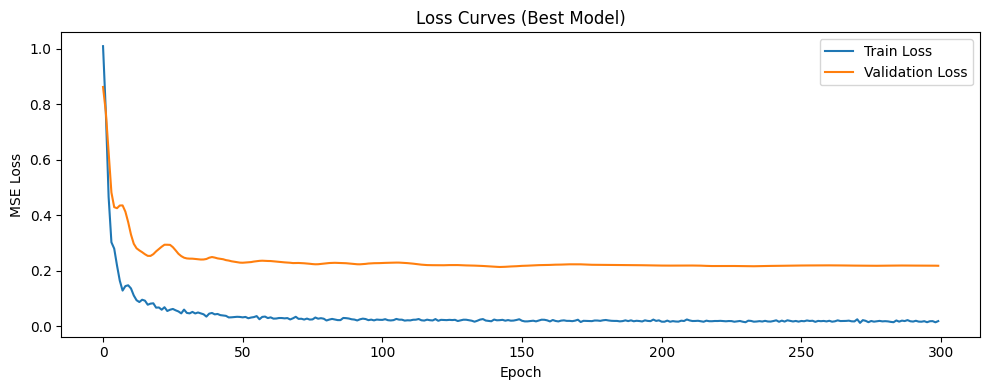

Loss curve saved to loss_curves.png


In [20]:
# ============================================================
# CELL 8 — Retrain best model + plot loss curves
# ============================================================
print("=" * 50)
print("RETRAINING BEST MODEL (300 epochs)")
print("=" * 50)

best_model, best_train_losses, best_val_losses = train_model(
    **best_params, epochs=300, verbose=True
)

print(f"\nFinal train loss: {best_train_losses[-1]:.4f}")
print(f"Final val loss:   {best_val_losses[-1]:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(best_train_losses, label='Train Loss')
plt.plot(best_val_losses,   label='Validation Loss')
plt.title("Loss Curves (Best Model)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()
print("Loss curve saved to loss_curves.png")

In [21]:
# ============================================================
# CELL 9 — Final evaluation
# ============================================================
print("=" * 50)
print("FINAL EVALUATION")
print("=" * 50)
best_model.eval()

with torch.no_grad():
    val_preds = best_model(X_val).numpy()
val_preds = scaler_y.inverse_transform(val_preds)
val_true  = scaler_y.inverse_transform(y_val.numpy())
val_rmse  = np.sqrt(mean_squared_error(val_true, val_preds))
val_r2    = r2_score(val_true, val_preds)
val_mae   = np.mean(np.abs(val_true - val_preds))

print(f"Validation set ({len(val_true)} samples):")
print(f"  RMSE: ${val_rmse:>10,.2f}")
print(f"  MAE:  ${val_mae:>10,.2f}")
print(f"  R²:        {val_r2:.4f}")

with torch.no_grad():
    test_preds = best_model(X_test).numpy()
test_preds = scaler_y.inverse_transform(test_preds)
test_true  = scaler_y.inverse_transform(y_test.numpy())
test_rmse  = np.sqrt(mean_squared_error(test_true, test_preds))
test_r2    = r2_score(test_true, test_preds)
test_mae   = np.mean(np.abs(test_true - test_preds))

print(f"\nTest set ({len(test_true)} samples):")
print(f"  RMSE: ${test_rmse:>10,.2f}")
print(f"  MAE:  ${test_mae:>10,.2f}")
print(f"  R²:        {test_r2:.4f}")

print(f"\nSample predictions (first 10 from test set):")
print(f"{'#':<4} {'Actual':>12} {'Predicted':>12} {'Error':>12} {'Error %':>8}")
print("-" * 52)
for i in range(min(10, len(test_true))):
    actual    = test_true[i][0]
    predicted = test_preds[i][0]
    error     = predicted - actual
    pct       = (error / actual) * 100
    print(f"{i+1:<4} ${actual:>11,.0f} ${predicted:>11,.0f} ${error:>+11,.0f} {pct:>+7.1f}%")

FINAL EVALUATION
Validation set (90 samples):
  RMSE: $  2,774.91
  MAE:  $  2,138.82
  R²:        0.7592

Test set (50 samples):
  RMSE: $  3,087.15
  MAE:  $  2,450.82
  R²:        0.7026

Sample predictions (first 10 from test set):
#          Actual    Predicted        Error  Error %
----------------------------------------------------
1    $     45,000 $     43,587 $     -1,413    -3.1%
2    $     45,000 $     44,481 $       -519    -1.2%
3    $     41,177 $     42,260 $     +1,083    +2.6%
4    $     45,000 $     44,352 $       -648    -1.4%
5    $     36,172 $     36,152 $        -20    -0.1%
6    $     35,371 $     33,118 $     -2,253    -6.4%
7    $     31,421 $     32,971 $     +1,550    +4.9%
8    $     45,000 $     41,814 $     -3,186    -7.1%
9    $     34,506 $     36,599 $     +2,093    +6.1%
10   $     36,707 $     37,795 $     +1,088    +3.0%


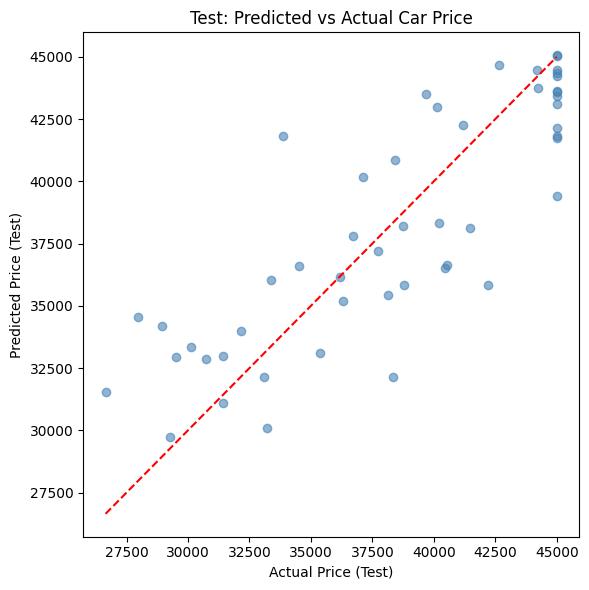

Scatter plot saved to car_test_pred_vs_actual.png


In [22]:
# ============================================================
# CELL 10 — Scatter plot
# ============================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_true, test_preds, alpha=0.6, color='steelblue')
plt.plot([test_true.min(), test_true.max()],
         [test_true.min(), test_true.max()], 'r--')
plt.xlabel("Actual Price (Test)")
plt.ylabel("Predicted Price (Test)")
plt.title("Test: Predicted vs Actual Car Price")
plt.tight_layout()
plt.savefig("car_test_pred_vs_actual.png", dpi=150)
plt.show()
print("Scatter plot saved to car_test_pred_vs_actual.png")

In [23]:
# ============================================================
# CELL 11 — Save model
# ============================================================
torch.save(best_model.state_dict(), "car_model_best.pth")
print("Model saved as car_model_best.pth")

from google.colab import files
files.download("car_model_best.pth")
files.download("loss_curves.png")
files.download("car_test_pred_vs_actual.png")
print("Files downloaded to your machine.")

Model saved as car_model_best.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded to your machine.


In [24]:
# ============================================================
# CELL 12 — Load & inference
# ============================================================
loaded_model = CarPriceModel(
    X_train.shape[1],
    hidden_size=best_params['hidden_size'],
    dropout=best_params['dropout']
)
loaded_model.load_state_dict(torch.load("car_model_best.pth"))
loaded_model.eval()

print("=" * 50)
print("INFERENCE CHECK (model reload test)")
print("=" * 50)

for i in range(min(5, len(X_test))):
    sample = X_test[i].unsqueeze(0)
    with torch.no_grad():
        pred = loaded_model(sample).numpy()
    pred_price   = scaler_y.inverse_transform(pred)[0][0]
    actual_price = test_true[i][0]
    diff         = pred_price - actual_price
    print(f"Sample {i+1}: Predicted=${pred_price:>10,.2f} | Actual=${actual_price:>10,.2f} | Diff=${diff:>+10,.2f}")

print("\nAll done.")

INFERENCE CHECK (model reload test)
Sample 1: Predicted=$ 43,587.36 | Actual=$ 45,000.00 | Diff=$ -1,412.64
Sample 2: Predicted=$ 44,480.88 | Actual=$ 45,000.00 | Diff=$   -519.12
Sample 3: Predicted=$ 42,259.72 | Actual=$ 41,177.00 | Diff=$ +1,082.72
Sample 4: Predicted=$ 44,352.19 | Actual=$ 45,000.00 | Diff=$   -647.81
Sample 5: Predicted=$ 36,152.05 | Actual=$ 36,172.00 | Diff=$    -19.95

All done.
